In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta


In [67]:
titanic_df = sns.load_dataset('titanic')
titanic_third=titanic_df[(titanic_df['pclass']==3) & (titanic_df['sex']=='male')]
# print(titanic_third)
survived=titanic_third[:150]['survived'].sum()
survived

22

In [68]:
def posterior(alpha,beta):
    return [alpha+survived,beta+150-survived]

In [69]:
prior_1=posterior(5,5)
mean_1=prior_1[0]/(prior_1[0]+prior_1[1])

prior_2=posterior(2,20)
mean_2=prior_2[0]/(prior_2[0]+prior_2[1])

prior_3=posterior(1,1)
mean_3=prior_3[0]/(prior_3[0]+prior_3[1])

true_mean=titanic_third['survived'].mean()
true_mean



0.13544668587896252

In [53]:
print(len(titanic_third['survived']))
print(sum(titanic_third['survived']))


347
47


Text(0.5, 0, 'Survival Probability')

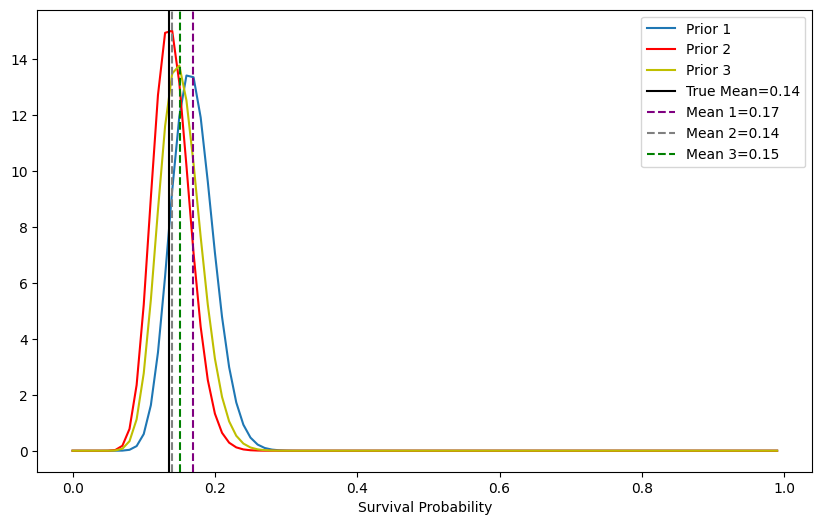

In [70]:
x=np.arange(0,1,0.01)
y1=beta.pdf(x,prior_1[0],prior_1[1])
y2=beta.pdf(x,prior_2[0],prior_2[1])
y3=beta.pdf(x,prior_3[0],prior_3[1])

plt.figure(figsize=(10,6))
plt.plot(x,y1,"-",x,y2,"r-",x,y3,"y-")
plt.axvline(true_mean,color="k",linestyle="-")
plt.axvline(mean_1,color="purple",linestyle="--")
plt.axvline(mean_2,color="grey",linestyle="--")
plt.axvline(mean_3,color="green",linestyle="--")

plt.legend(["Prior 1","Prior 2","Prior 3","True Mean={:.2f}".format(true_mean),"Mean 1={:.2f}".format(mean_1),"Mean 2={:.2f}".format(mean_2),"Mean 3={:.2f}".format(mean_3)])
plt.xlabel("Survival Probability")


# Comments:

Random Survival performed worst while uninformed prior seemed to work best


## Monte Carlo Simulation for Beta Priors


In [55]:
# Monte Carlo Sampling for Beta priors
from scipy.stats import binom
N = 100000  # Number of Monte Carlo samples

def monte_carlo_posterior(alpha_prior, beta_prior, n_samples=N):
    theta_samples = np.random.beta(alpha_prior, beta_prior, n_samples) #Sampling N thetas from prior
    
    likelihoods = binom.pmf(survived, 50, theta_samples) #p(X|theta)
    
    # Calculate weights 
    weights = likelihoods
    weights = weights / weights.sum()  # Normalize
    
    # Posterior mean
    posterior_mean = np.sum(theta_samples * weights)
    
    return theta_samples, weights, posterior_mean

mc_results = []
for i, (alpha, beta_val) in enumerate([(5, 5), (2, 20), (1, 1)], 1):
    theta_samples, weights, post_mean = monte_carlo_posterior(alpha, beta_val)
    mc_results.append((theta_samples, weights, post_mean))
    print(f"Prior {i} (alpha={alpha}, beta={beta_val}): MC Posterior Mean = {post_mean:.4f}")

# Compare with theoretical means
print(f"\nTheoretical Posterior Means:")
print(f"Prior 1: {mean_1:.4f}")
print(f"Prior 2: {mean_2:.4f}")
print(f"Prior 3: {mean_3:.4f}")

Prior 1 (alpha=5, beta=5): MC Posterior Mean = 0.1830
Prior 2 (alpha=2, beta=20): MC Posterior Mean = 0.1111
Prior 3 (alpha=1, beta=1): MC Posterior Mean = 0.1346

Theoretical Posterior Means:
Prior 1: 0.1833
Prior 2: 0.1111
Prior 3: 0.1346


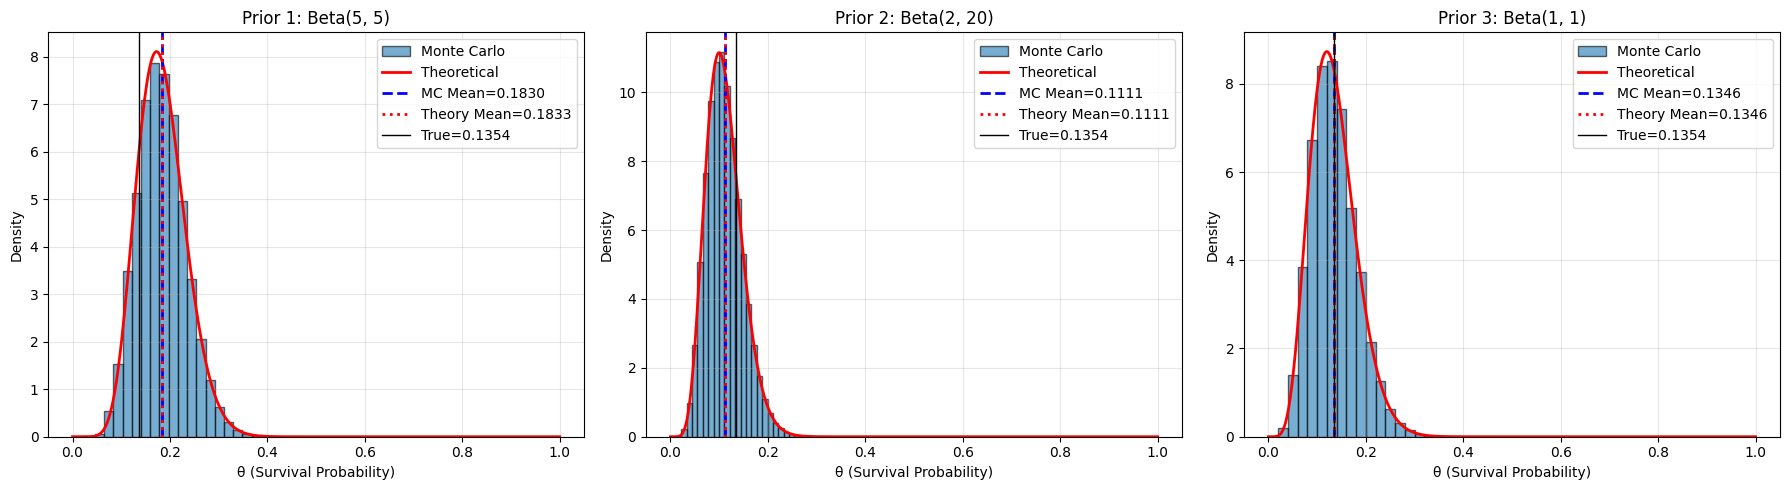

In [56]:
# Plot comparison between Monte Carlo and Theoretical posteriors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ax, (theta_samples, weights, mc_mean), prior_params, theory_mean) in enumerate(
    zip(axes, mc_results, [(5,5), (2,20), (1,1)], [mean_1, mean_2, mean_3]), 1):
    
    # Plot histogram of Monte Carlo samples (weighted)
    ax.hist(theta_samples, bins=50, weights=weights, density=True, alpha=0.6, 
            label='Monte Carlo', edgecolor='black')
    
    # Plot theoretical posterior
    x = np.linspace(0, 1, 1000)
    alpha_post, beta_post = posterior(prior_params[0], prior_params[1])
    y_theory = beta.pdf(x, alpha_post, beta_post)
    ax.plot(x, y_theory, 'r-', linewidth=2, label='Theoretical')
    
    # Add vertical lines for means
    ax.axvline(mc_mean, color='blue', linestyle='--', linewidth=2, label=f'MC Mean={mc_mean:.4f}')
    ax.axvline(theory_mean, color='red', linestyle=':', linewidth=2, label=f'Theory Mean={theory_mean:.4f}')
    ax.axvline(true_mean, color='black', linestyle='-', linewidth=1, label=f'True={true_mean:.4f}')
    
    ax.set_xlabel('θ (Survival Probability)')
    ax.set_ylabel('Density')
    ax.set_title(f'Prior {i}: Beta({prior_params[0]}, {prior_params[1]})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Prior p(theta) ∝ |sin(pi * theta)| 

In [57]:
def sample_from_prior_rejection(prior_func, n_samples, max_prior):
    """
    Sample from prior distribution using rejection sampling
    """
    samples = []
    while len(samples) < n_samples:
        # Propose uniform samples
        theta_prop = np.random.uniform(0, 1, n_samples)
        u = np.random.uniform(0, 1, n_samples)
        
        # Accept/reject
        accept = u < (prior_func(theta_prop) / max_prior)
        samples.extend(theta_prop[accept])
    
    return np.array(samples[:n_samples])

def monte_carlo_nonconjugate(prior_func, max_prior, n_samples=N):
    """
    Perform Monte Carlo sampling for non-conjugate priors
    CORRECT implementation: Sample FROM the prior, weight by likelihood only
    """
    # Sample theta values from the prior distribution p(theta)
    theta_samples = sample_from_prior_rejection(prior_func, n_samples, max_prior)
    
    # Calculate likelihood for each theta: p(x^n | theta)
    from scipy.stats import binom
    likelihoods = binom.pmf(survived, 50, theta_samples)
    
    # Calculate weights (only based on likelihood as per formula)
    weights = likelihoods
    weights = weights / weights.sum()  # Normalize
    
    # Posterior mean: sum(theta_i * w_i)
    posterior_mean = np.sum(theta_samples * weights)
    
    return theta_samples, weights, posterior_mean

# Define the |sin(πθ)| prior
def sin_prior(theta):
    return np.abs(np.sin(np.pi * theta))

# Compute normalization constant for sin prior
x_norm = np.linspace(0, 1, 10000)
sin_norm_const = np.trapz(sin_prior(x_norm), x_norm)

def normalized_sin_prior(theta):
    return sin_prior(theta) / sin_norm_const

# Find max of normalized prior for rejection sampling
max_sin_prior = np.max(normalized_sin_prior(x_norm))

# Run Monte Carlo
theta_sin, weights_sin, mean_sin = monte_carlo_nonconjugate(normalized_sin_prior, max_sin_prior)
print(f"|sin(πθ)| Prior: Posterior Mean = {mean_sin:.4f}")
print(f"True Mean: {true_mean:.4f}")

|sin(πθ)| Prior: Posterior Mean = 0.1501
True Mean: 0.1354


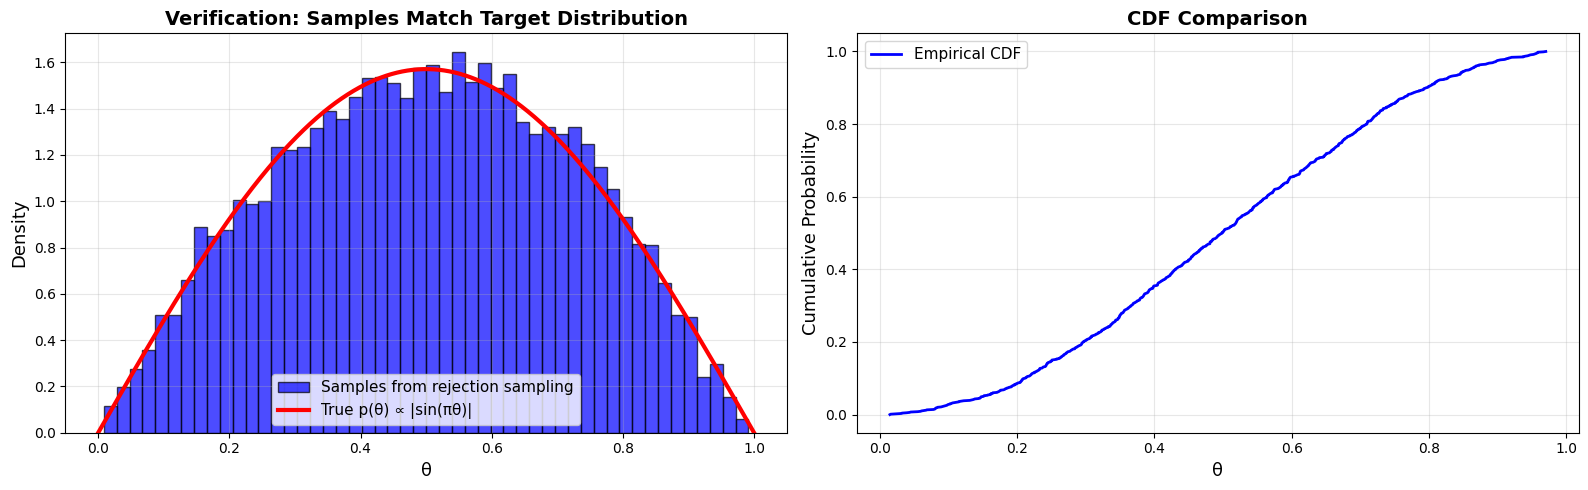

In [58]:
# Compare: histogram of samples from rejection sampling vs. target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sample a moderate number for visualization
np.random.seed(123)
n_vis = 10000
samples_vis = sample_from_prior_rejection(normalized_sin_prior, n_vis, max_sin_prior)

# Left: Histogram of samples
ax1 = axes[0]
ax1.hist(samples_vis, bins=50, density=True, alpha=0.7, color='blue', 
         edgecolor='black', label='Samples from rejection sampling')
ax1.plot(x_plot, sin_density, 'r-', linewidth=3, label='True p(θ) ∝ |sin(πθ)|')
ax1.set_xlabel('θ', fontsize=13)
ax1.set_ylabel('Density', fontsize=13)
ax1.set_title('Verification: Samples Match Target Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Show how samples are distributed
ax2 = axes[1]
sorted_samples = np.sort(samples_vis[:1000])
ax2.plot(sorted_samples, np.linspace(0, 1, len(sorted_samples)), 
         'b-', linewidth=2, label='Empirical CDF')

# Compute true CDF by integrating the PDF
# from scipy.integrate import cumtrapz
# cdf_true = cumtrapz(sin_density, x_plot, initial=0)
# cdf_true = cdf_true / cdf_true[-1]  # Normalize
# ax2.plot(x_plot, cdf_true, 'r--', linewidth=2, label='True CDF')

ax2.set_xlabel('θ', fontsize=13)
ax2.set_ylabel('Cumulative Probability', fontsize=13)
ax2.set_title('CDF Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

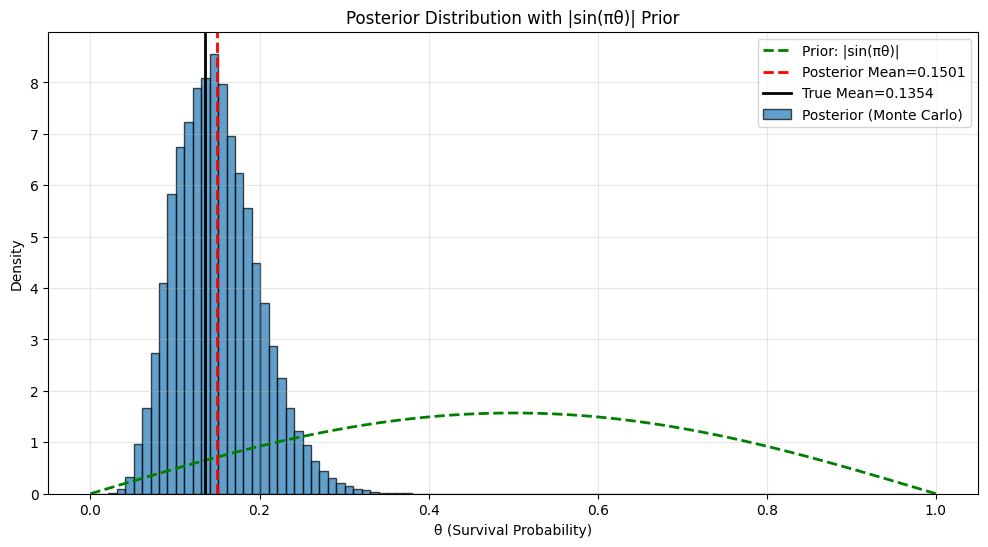

In [59]:
# Plot posterior distribution for |sin(πθ)| prior
plt.figure(figsize=(12, 6))

# Plot histogram using np.histogram for better control
hist, bin_edges = np.histogram(theta_sin, bins=100, weights=weights_sin, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist, width=bin_edges[1]-bin_edges[0], alpha=0.7, 
        edgecolor='black', label='Posterior (Monte Carlo)')

# Plot the prior
x = np.linspace(0, 1, 1000)
plt.plot(x, normalized_sin_prior(x), 'g--', linewidth=2, label='Prior: |sin(πθ)|')

# Add mean lines
plt.axvline(mean_sin, color='red', linestyle='--', linewidth=2, label=f'Posterior Mean={mean_sin:.4f}')
plt.axvline(true_mean, color='black', linestyle='-', linewidth=2, label=f'True Mean={true_mean:.4f}')

plt.xlabel('θ (Survival Probability)')
plt.ylabel('Density')
plt.title('Posterior Distribution with |sin(πθ)| Prior')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 3: Prior p(θ) ∝ |cos(πθ)| for θ ∈ [0,1]

In [60]:
# Define the |cos(πθ)| prior
def cos_prior(theta):
    return np.abs(np.cos(np.pi * theta))

# Compute normalization constant for cos prior
cos_norm_const = np.trapz(cos_prior(x_norm), x_norm)

def normalized_cos_prior(theta):
    return cos_prior(theta) / cos_norm_const

# Find max of normalized prior for rejection sampling
max_cos_prior = np.max(normalized_cos_prior(x_norm))

# Run Monte Carlo
theta_cos, weights_cos, mean_cos = monte_carlo_nonconjugate(normalized_cos_prior, max_cos_prior)
print(f"|cos(πθ)| Prior: Posterior Mean = {mean_cos:.4f}")
print(f"True Mean: {true_mean:.4f}")

|cos(πθ)| Prior: Posterior Mean = 0.1312
True Mean: 0.1354


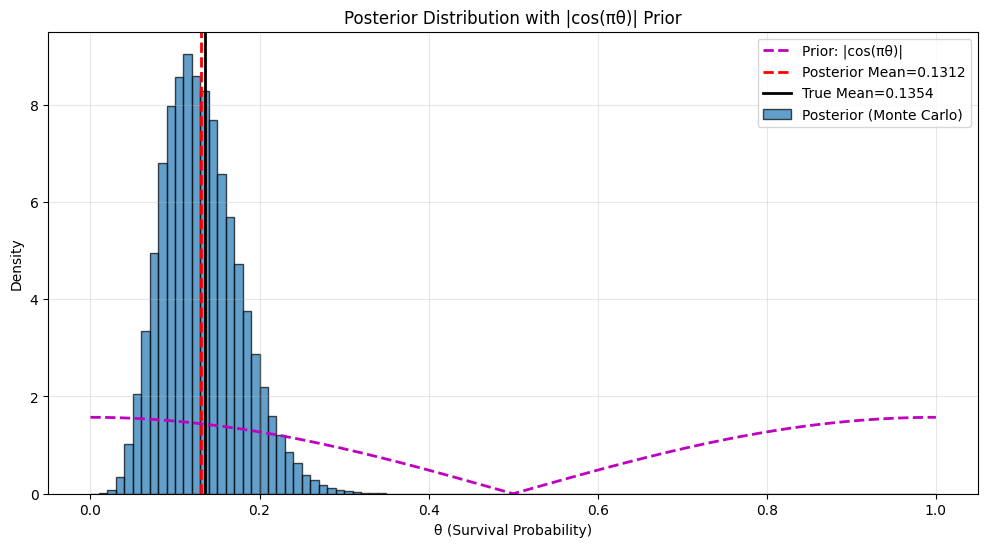

In [61]:
# Plot posterior distribution for |cos(πθ)| prior
plt.figure(figsize=(12, 6))

# Plot histogram
hist, bin_edges = np.histogram(theta_cos, bins=100, weights=weights_cos, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist, width=bin_edges[1]-bin_edges[0], alpha=0.7, 
        edgecolor='black', label='Posterior (Monte Carlo)')

# Plot the prior
x = np.linspace(0, 1, 1000)
plt.plot(x, normalized_cos_prior(x), 'm--', linewidth=2, label='Prior: |cos(πθ)|')

# Add mean lines
plt.axvline(mean_cos, color='red', linestyle='--', linewidth=2, label=f'Posterior Mean={mean_cos:.4f}')
plt.axvline(true_mean, color='black', linestyle='-', linewidth=2, label=f'True Mean={true_mean:.4f}')

plt.xlabel('θ (Survival Probability)')
plt.ylabel('Density')
plt.title('Posterior Distribution with |cos(πθ)| Prior')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Custom Prior - Triangular Distribution p(θ) ∝ θ(1-θ) for θ ∈ [0,1]

In [62]:
# Define a custom prior: θ(1-θ) which puts more weight near the middle
def custom_prior(theta):
    return theta * (1 - theta)

# Compute normalization constant
custom_norm_const = np.trapz(custom_prior(x_norm), x_norm)

def normalized_custom_prior(theta):
    return custom_prior(theta) / custom_norm_const

# Find max of normalized prior for rejection sampling
max_custom_prior = np.max(normalized_custom_prior(x_norm))

# Run Monte Carlo
theta_custom, weights_custom, mean_custom = monte_carlo_nonconjugate(normalized_custom_prior, max_custom_prior)
print(f"Custom Prior θ(1-θ): Posterior Mean = {mean_custom:.4f}")
print(f"True Mean: {true_mean:.4f}")

Custom Prior θ(1-θ): Posterior Mean = 0.1479
True Mean: 0.1354


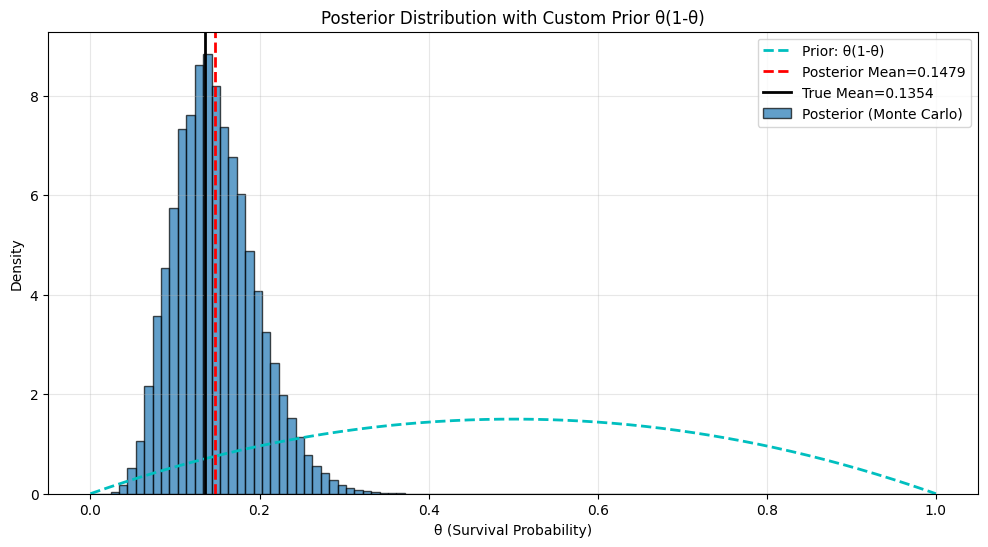

In [63]:
# Plot posterior distribution for custom prior
plt.figure(figsize=(12, 6))

# Plot histogram
hist, bin_edges = np.histogram(theta_custom, bins=100, weights=weights_custom, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist, width=bin_edges[1]-bin_edges[0], alpha=0.7, 
        edgecolor='black', label='Posterior (Monte Carlo)')

# Plot the prior
x = np.linspace(0, 1, 1000)
plt.plot(x, normalized_custom_prior(x), 'c--', linewidth=2, label='Prior: θ(1-θ)')

# Add mean lines
plt.axvline(mean_custom, color='red', linestyle='--', linewidth=2, label=f'Posterior Mean={mean_custom:.4f}')
plt.axvline(true_mean, color='black', linestyle='-', linewidth=2, label=f'True Mean={true_mean:.4f}')

plt.xlabel('θ (Survival Probability)')
plt.ylabel('Density')
plt.title('Posterior Distribution with Custom Prior θ(1-θ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

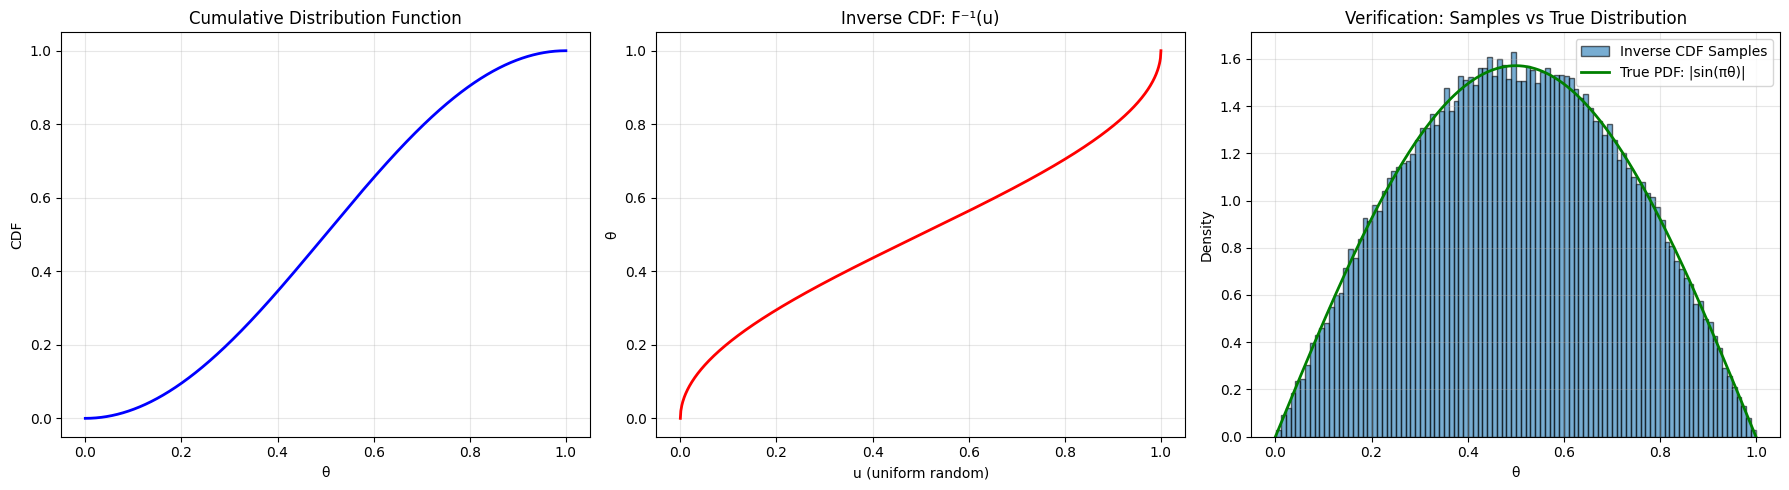

Inverse CDF Method:
  Mean of samples: 0.499520
  Theoretical mean: 0.500000

Rejection Sampling (previous method):
  Mean of samples: 0.500514


In [64]:
# Inverse CDF Method for |sin(πθ)|
# For |sin(πθ)| on [0,1], we need to compute CDF numerically and invert it

# Step 1: Create fine grid for CDF computation
theta_grid = np.linspace(0, 1, 10000)
pdf_values = normalized_sin_prior(theta_grid)

# Step 2: Compute CDF using cumulative trapezoidal integration
from scipy.integrate import cumulative_trapezoid
cdf_values = cumulative_trapezoid(pdf_values, theta_grid, initial=0)
cdf_values = cdf_values / cdf_values[-1]  # Normalize to ensure CDF(1) = 1

# Step 3: Create inverse CDF function using interpolation
from scipy.interpolate import interp1d
inverse_cdf = interp1d(cdf_values, theta_grid, kind='linear', bounds_error=False, fill_value=(0, 1))

# Step 4: Sample using inverse CDF method
u_samples = np.random.uniform(0, 1, N)
theta_sin_inverse = inverse_cdf(u_samples)

# Verify the sampling worked by plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CDF
axes[0].plot(theta_grid, cdf_values, 'b-', linewidth=2)
axes[0].set_xlabel('θ')
axes[0].set_ylabel('CDF')
axes[0].set_title('Cumulative Distribution Function')
axes[0].grid(True, alpha=0.3)

# Plot 2: Inverse CDF
u_plot = np.linspace(0, 1, 1000)
theta_plot = inverse_cdf(u_plot)
axes[1].plot(u_plot, theta_plot, 'r-', linewidth=2)
axes[1].set_xlabel('u (uniform random)')
axes[1].set_ylabel('θ')
axes[1].set_title('Inverse CDF: F⁻¹(u)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Compare sampled distribution with true PDF
axes[2].hist(theta_sin_inverse, bins=100, density=True, alpha=0.6, edgecolor='black', label='Inverse CDF Samples')
axes[2].plot(theta_grid, pdf_values, 'g-', linewidth=2, label='True PDF: |sin(πθ)|')
axes[2].set_xlabel('θ')
axes[2].set_ylabel('Density')
axes[2].set_title('Verification: Samples vs True Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Inverse CDF Method:")
print(f"  Mean of samples: {np.mean(theta_sin_inverse):.6f}")
print(f"  Theoretical mean: {np.trapz(theta_grid * pdf_values, theta_grid):.6f}")
print(f"\nRejection Sampling (previous method):")
print(f"  Mean of samples: {np.mean(theta_sin):.6f}")